In [86]:
import json
from collections import defaultdict
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scienceplots



In [87]:
output_dir = '/home/slim/dpo-rhlf-paraphrase-types/out/plots'

textwidth2 = 3.08102 #twocolumn
textwidth1 = 6.30045 #onecolumn
aspect_ratio = (5 ** 0.5 - 1) / 2 # golden ratio
width1 = textwidth1
height1 = width1 * aspect_ratio
width2 = textwidth2
height2 = width2 * aspect_ratio
textwidthcm=15.99773 #onecolumn
textwidthcm=7.82315 #twocolumn
textheightcm=textwidthcm / aspect_ratio

# Results
## Effectiveness of DPO and RHLF in Paraphrase Generation

In [88]:
# Load the JSON data
with open('/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json', 'r') as file:
    data = json.load(file)

# Dictionary to store counts for each model
model_results = defaultdict(lambda: {'yes': 0, 'total': 0})

# Iterate through each entry in the JSON data
for entry in data:
    kind = entry['data']['Kind']
    # Check the "APT" choice value in the annotations
    for annotation in entry['annotations']:
        for result in annotation['result']:
            if result['from_name'] == "APT":
                choice = result['value']['choices'][0]
                model_results[kind]['total'] += 1
                if choice == "Yes":
                    model_results[kind]['yes'] += 1

# Calculate accuracy for each model
apt_percentages = {model: (counts['yes'] / counts['total']) * 100
                  for model, counts in model_results.items()}


print(apt_percentages)


{'base_model': 12.376237623762377, 'etpc_model': 11.76470588235294, 'dpo_model': 35.26315789473684}


In [89]:
# Dictionary to store counts for each (model, APT) pair
results = defaultdict(lambda: {'yes': 0, 'total': 0})

# Iterate through each entry in the JSON data
for entry in data:
    # Ensure entry is a dictionary before processing
    if isinstance(entry, dict):
        kind = entry.get('data', {}).get('Kind')
        apt_value = entry.get('data', {}).get('APT')
        
        # Proceed only if both kind and apt_value are found
        if kind and apt_value:
            annotations = entry.get('annotations', [])
            
            # Check if there are annotations
            if annotations:
                for annotation in annotations:
                    results_found = annotation.get('result', [])
                    
                    # Iterate through each result within the annotation
                    for result in results_found:
                        from_name = result.get('from_name')
                        
                        # Focus on results where from_name is "APT"
                        if from_name == "APT":
                            choice = result.get('value', {}).get('choices', [None])[0]
                            
                            # Check if the choice is valid
                            if choice:
                                results[(kind, apt_value)]['total'] += 1
                                if choice == "Yes":
                                    results[(kind, apt_value)]['yes'] += 1

# Calculate accuracy for each (model, APT) pair
apt_percentages = {
    (model, apt): (counts['yes'] / counts['total']) * 100
    for (model, apt), counts in results.items()
    if counts['total'] > 0  # Avoid division by zero
}

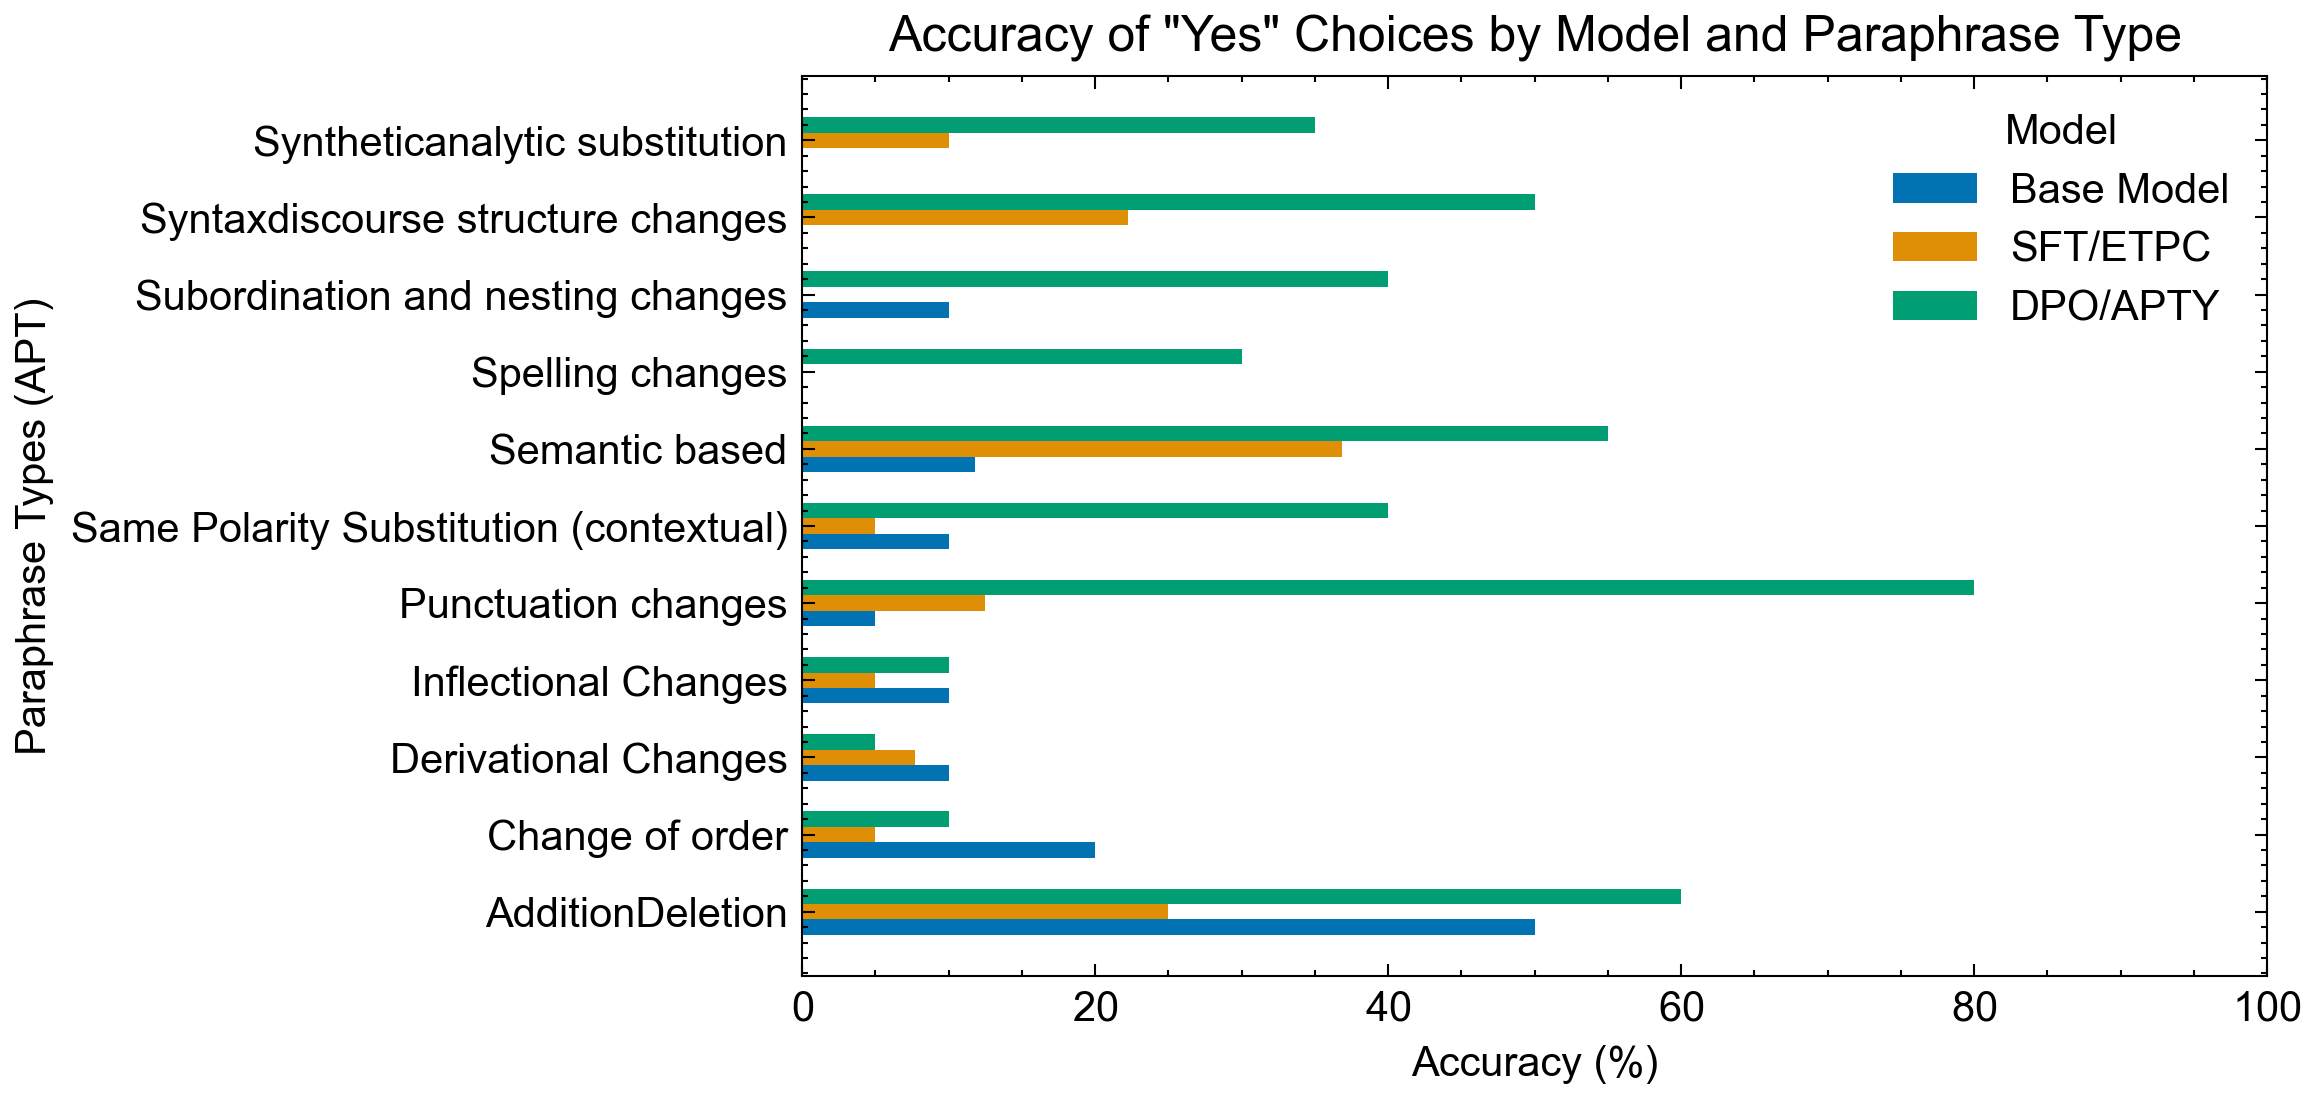

In [99]:
# Create a set of unique APT values and models in the specified order
apt_values = sorted(set(apt for _, apt in apt_percentages.keys()))
models = ["base_model", "etpc_model", "dpo_model"]  # Ordered list of models
model_labels = {
    "base_model": "Base Model",
    "etpc_model": "SFT/ETPC",
    "dpo_model": "DPO/APTY"
}

# Create data for plotting
y = np.arange(len(apt_values))  # the label locations for the y-axis
width = 0.2  # the width of the bars

# Create a dictionary to hold accuracy values for each model across APTs
model_accuracies = {
    model: [apt_percentages.get((model, apt), 0) for apt in apt_values]
    for model in models
}

# Create the plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# Plot each model's accuracy as a separate set of horizontal bars
for i, model in enumerate(models):
    plt.barh(y + i * width, model_accuracies[model], height=width, label=model_labels[model])

# Add labels and title
plt.ylabel('Paraphrase Types (APT)')
plt.xlabel('Accuracy (%)')
plt.title('Accuracy of "Yes" Choices by Model and Paraphrase Type')
plt.yticks(y + width * (len(models) - 1) / 2, apt_values, fontsize=10)
plt.xlim(0, 100)  # Set x-axis limit to 100% for consistency
plt.legend(title='Model', fontsize=10)

# Display the plot
plt.show()


## Incorporating Human-Ranked Data for Improved Paraphrase Generation

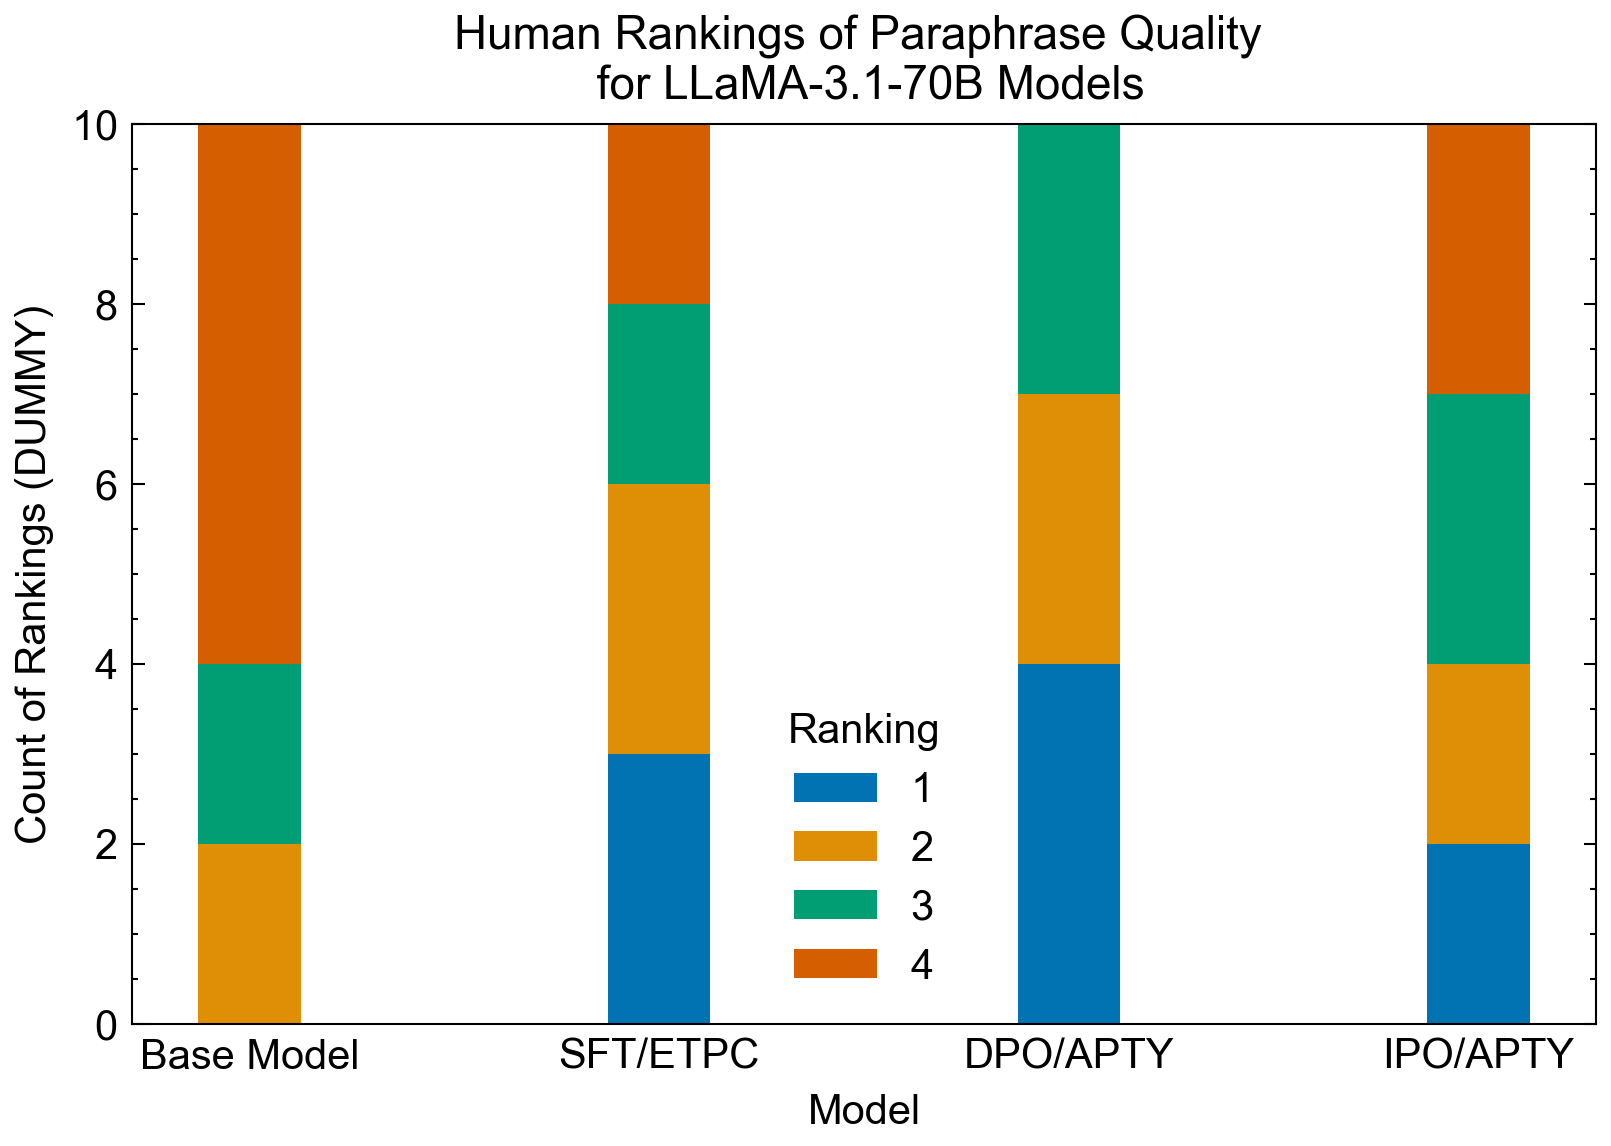

In [91]:
# Adding the base model rankings to the dummy data
data_with_base = {
    "Base Model": [4, 4, 4, 2, 4, 4, 3, 4, 2, 3],
    "SFT/ETPC": [1, 2, 3, 1, 2, 3, 4, 2, 1, 4],
    "DPO/APTY": [2, 1, 1, 3, 3, 2, 2, 1, 3, 1],
    "IPO/APTY": [3, 3, 2, 4, 1, 4, 1, 3, 4, 2]
}

# Convert updated data to a DataFrame
df_with_base = pd.DataFrame(data_with_base)

# Count how often each model got each ranking (1 to 4)
rank_counts_with_base = df_with_base.apply(lambda col: col.value_counts()).fillna(0).astype(int)

# Transpose for better plotting (stacked bar chart)
rank_counts_with_base = rank_counts_with_base.transpose()

# Plot the stacked bar chart with the base model
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

index = range(len(rank_counts_with_base))

for i, col in enumerate(rank_counts_with_base.columns):
    ax.bar(index, rank_counts_with_base[col], bar_width, bottom=rank_counts_with_base.iloc[:, :i].sum(axis=1))

# Set x-tick labels to the model names
ax.set_xticks(index)
ax.set_xticklabels(rank_counts_with_base.index, fontsize=10)


# Add labels and title
ax.set_xlabel('Model', fontsize=10)
ax.set_ylabel('Count of Rankings (DUMMY)', fontsize=10)
ax.set_title('Human Rankings of Paraphrase Quality \n for LLaMA-3.1-70B Models', fontsize=11)


# Add legend
ax.legend(rank_counts_with_base.columns, title="Ranking", frameon=False, fontsize=10)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis

output_path = os.path.join(output_dir, "apt_ranking.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

## Broader NLP Task Improvements with Human-Ranked Data

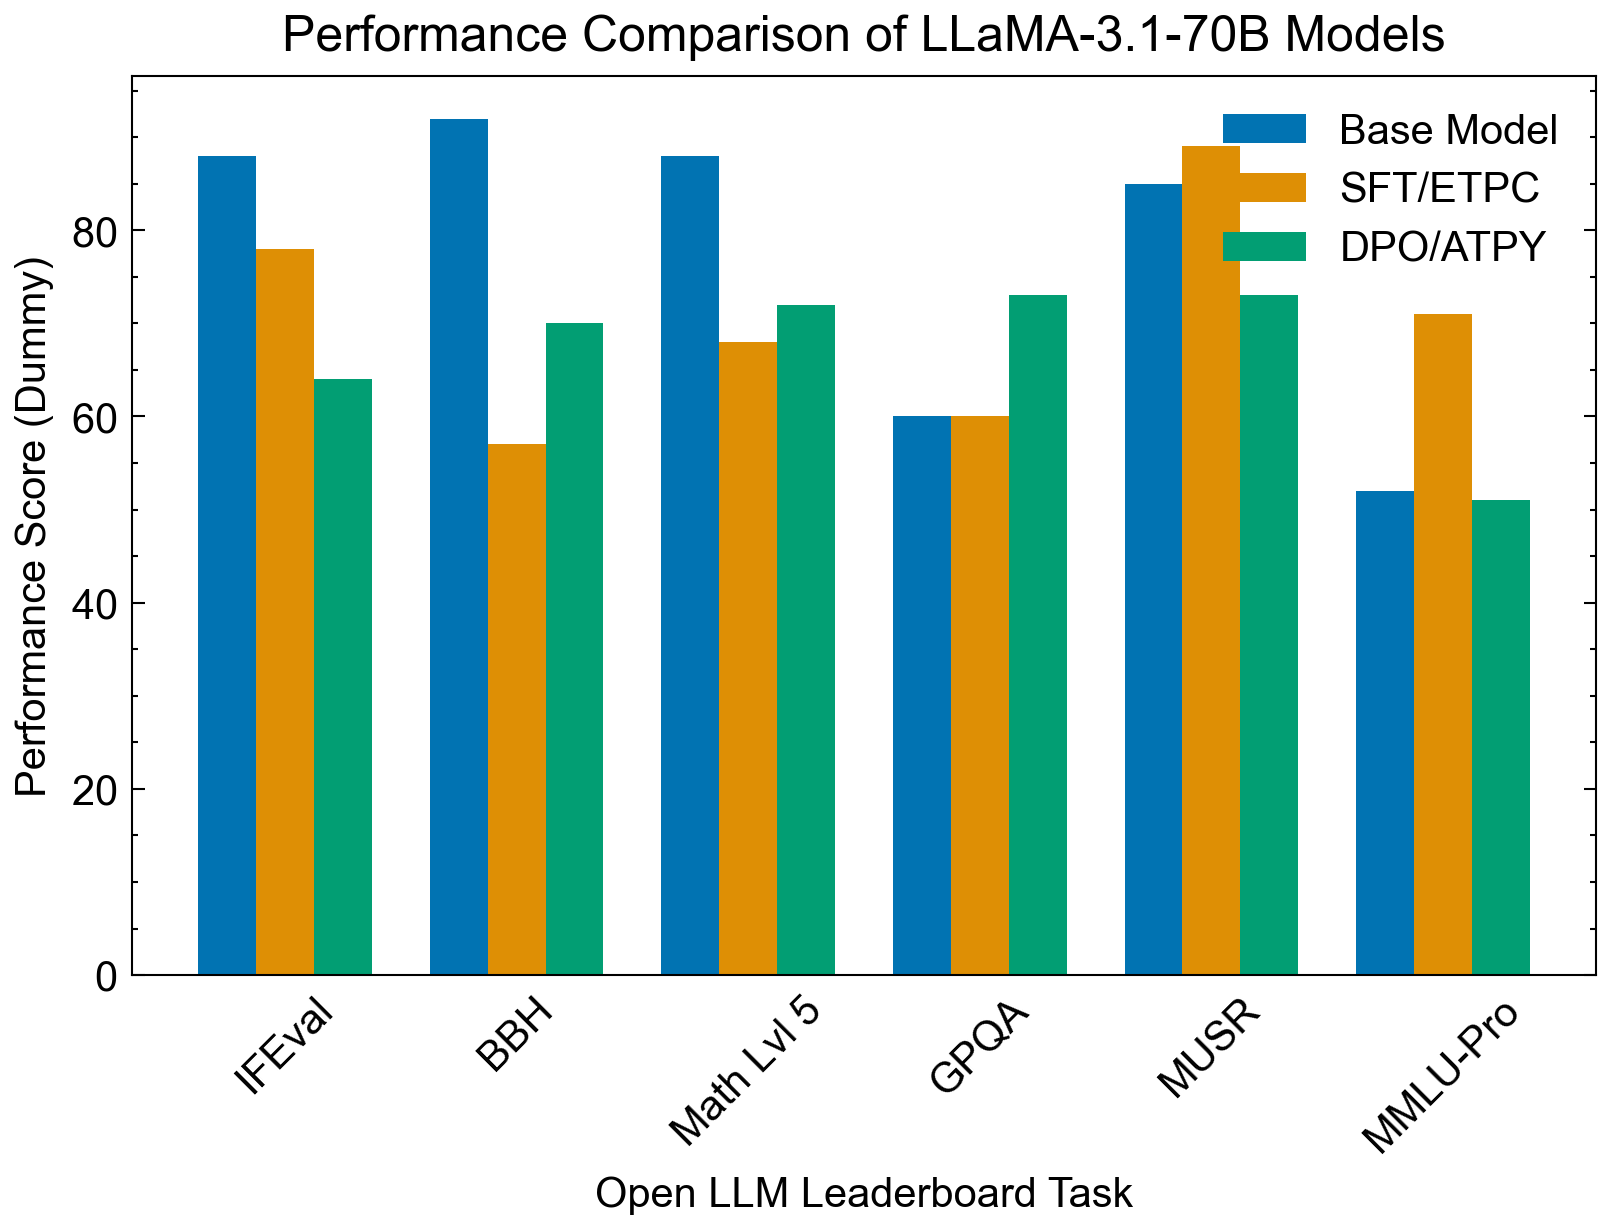

In [92]:
# Define tasks and models
tasks = ['IFEval', 'BBH', 'Math Lvl 5', 'GPQA', 'MUSR', 'MMLU-Pro']
models = ['Base Model', 'SFT/ETPC', 'DPO/ATPY']

# Create dummy scores for each task and model
np.random.seed(42)
scores = np.random.randint(50, 100, size=(len(tasks), len(models)))

# Create a grouped bar chart
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
bar_width = 0.25
index = np.arange(len(tasks))

# Plot bars for each model
for i, model in enumerate(models):
    ax.bar(index + i * bar_width, scores[:, i], bar_width, label=model)

# Set labels, title, and ticks
ax.set_xlabel('Open LLM Leaderboard Task', fontsize=10)
ax.set_ylabel('Performance Score (Dummy)', fontsize=10)
ax.set_title('Performance Comparison of LLaMA-3.1-70B Models', fontsize=12)
ax.set_xticks(index + bar_width)
ax.set_xticklabels(tasks)

# Add legend
ax.legend(fontsize=10)

# Rotate task labels for readability
plt.xticks(rotation=45)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis

output_path = os.path.join(output_dir, "llmboard.pdf")
plt.savefig(output_path, dpi=300)

plt.show()


## Correlation Between Automatic Metrics and Human Judgment

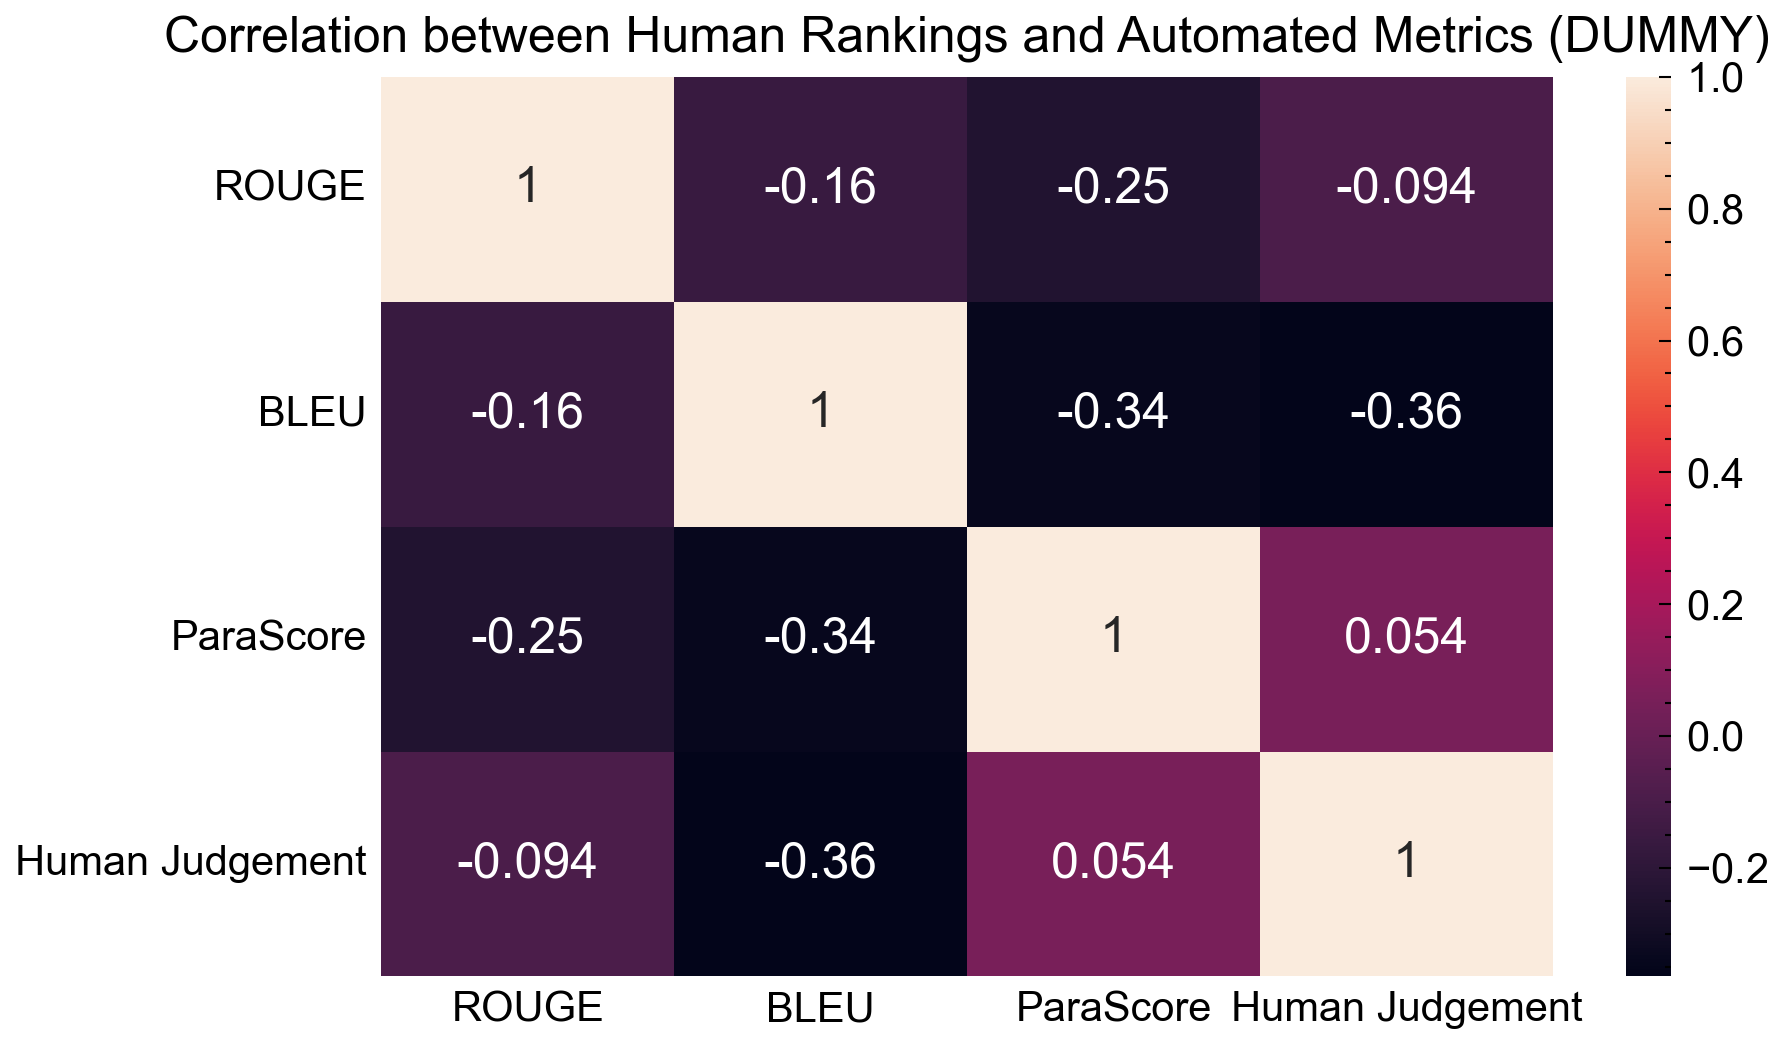

In [93]:
# Generate dummy scores for human rankings and automated metrics (ROUGE, BLEU, ParaScore)
rouge_scores = np.random.uniform(0.4, 0.9, size=10)  # ROUGE scores
bleu_scores = np.random.uniform(0.3, 0.8, size=10)  # BLEU scores
parascale_scores = np.random.uniform(0.5, 0.95, size=10)  # ParaScore
human_scores = np.random.uniform(0.5, 0.95, size=10) 

# Create a DataFrame for correlation matrix
data = {
    'ROUGE': rouge_scores,
    'BLEU': bleu_scores,
    'ParaScore': parascale_scores,
    'Human Judgement': human_scores
}
df = pd.DataFrame(data)

# Calculate the correlation matrix
corr_matrix = df.corr()

# Set figure size according to the provided description


# Create a heatmap for the correlation matrix
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
sns.heatmap(corr_matrix, annot=True, ax=ax, annot_kws={"fontsize": 12})

# Add title
plt.title('Correlation between Human Rankings and Automated Metrics (DUMMY)', fontsize=12)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis
ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis

# Save the correlation matrix as a PDF
output_path = os.path.join(output_dir, "correlation_matrix.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()


## New metric

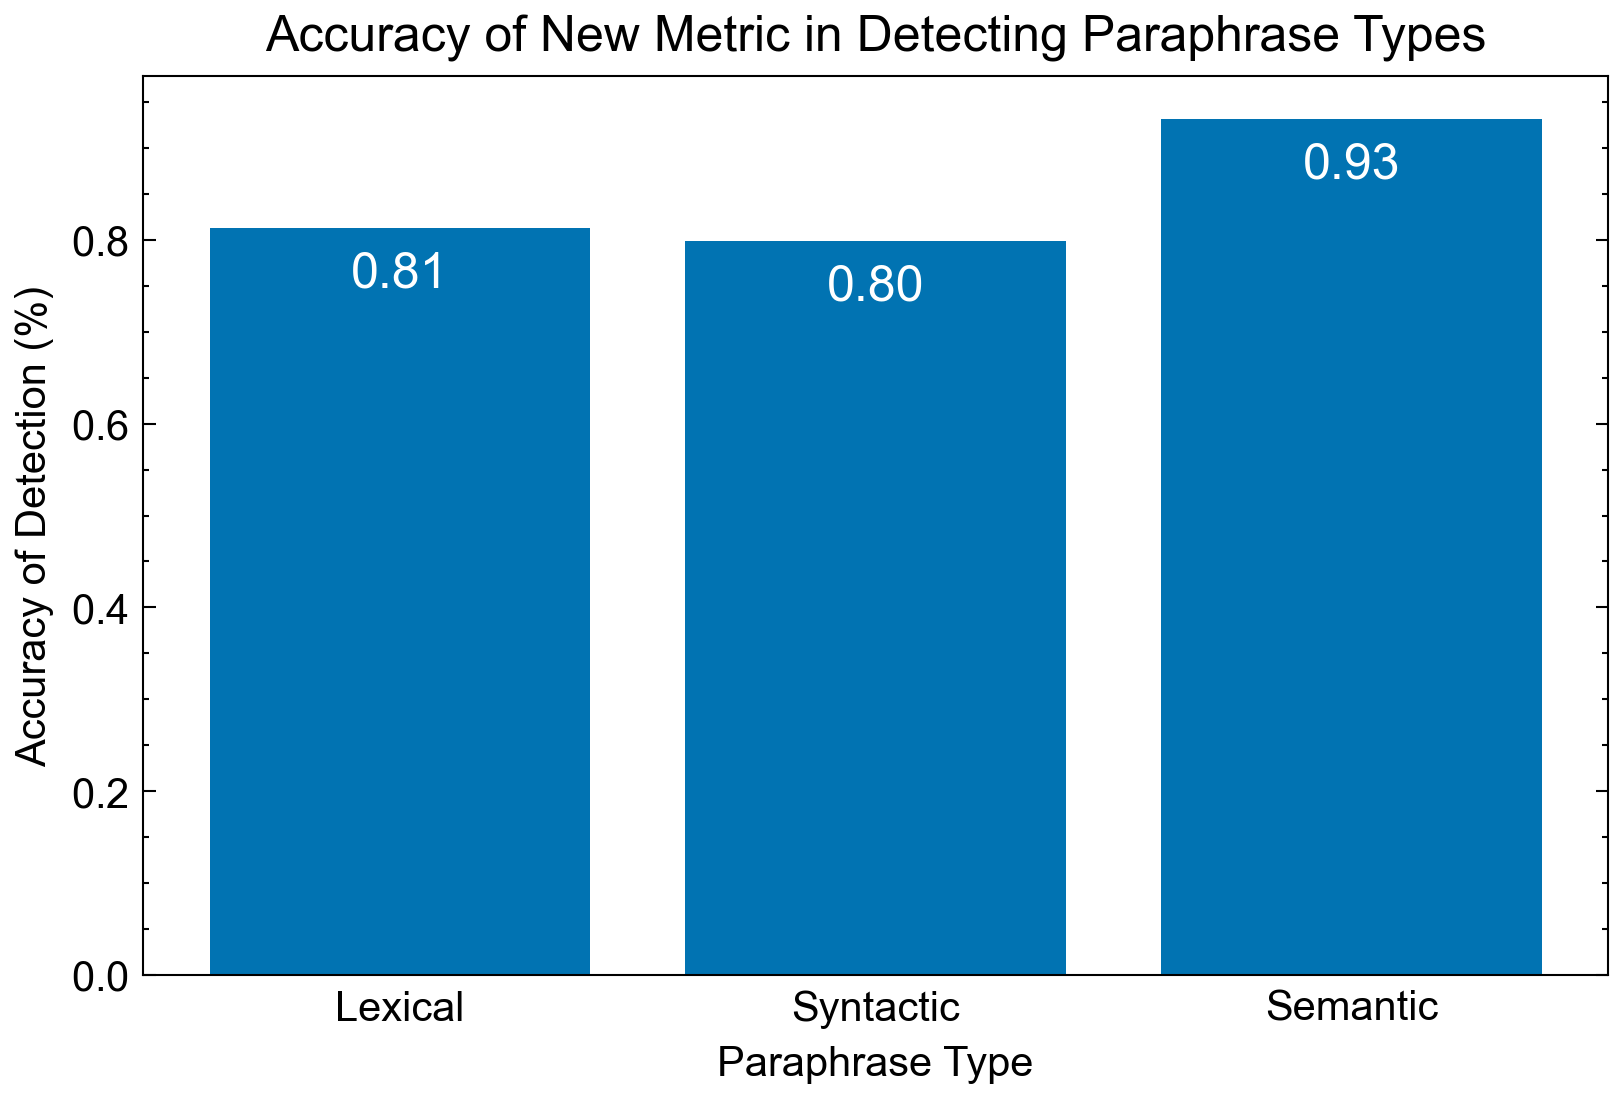

In [94]:

# Create dummy data for the accuracy of the new metric at detecting paraphrase types
paraphrase_types = ['Lexical', 'Syntactic', 'Semantic']
accuracy_scores = np.random.uniform(0.7, 0.95, size=len(paraphrase_types))  # Dummy accuracy values

# Create a DataFrame for the data
df_accuracy = pd.DataFrame({
    'Paraphrase Type': paraphrase_types,
    'Accuracy': accuracy_scores
})

# Set figure size

fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# Create a bar chart to show the accuracy for each paraphrase type
ax.bar(df_accuracy['Paraphrase Type'], df_accuracy['Accuracy'])

# Add labels and title
ax.set_xlabel('Paraphrase Type', fontsize=10)
ax.set_ylabel('Accuracy of Detection (%)', fontsize=10)
ax.set_title('Accuracy of New Metric in Detecting Paraphrase Types', fontsize=12)

# Add accuracy values on top of each bar
for i, v in enumerate(accuracy_scores):
    ax.text(i, v - 0.05, f"{v:.2f}", ha='center', va="center",color="white", fontsize=12)

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis

# Save as a PDF
output_path = os.path.join(output_dir, "newaccuracy.pdf")
plt.savefig(output_path, dpi=300)

# Show plot
plt.show()


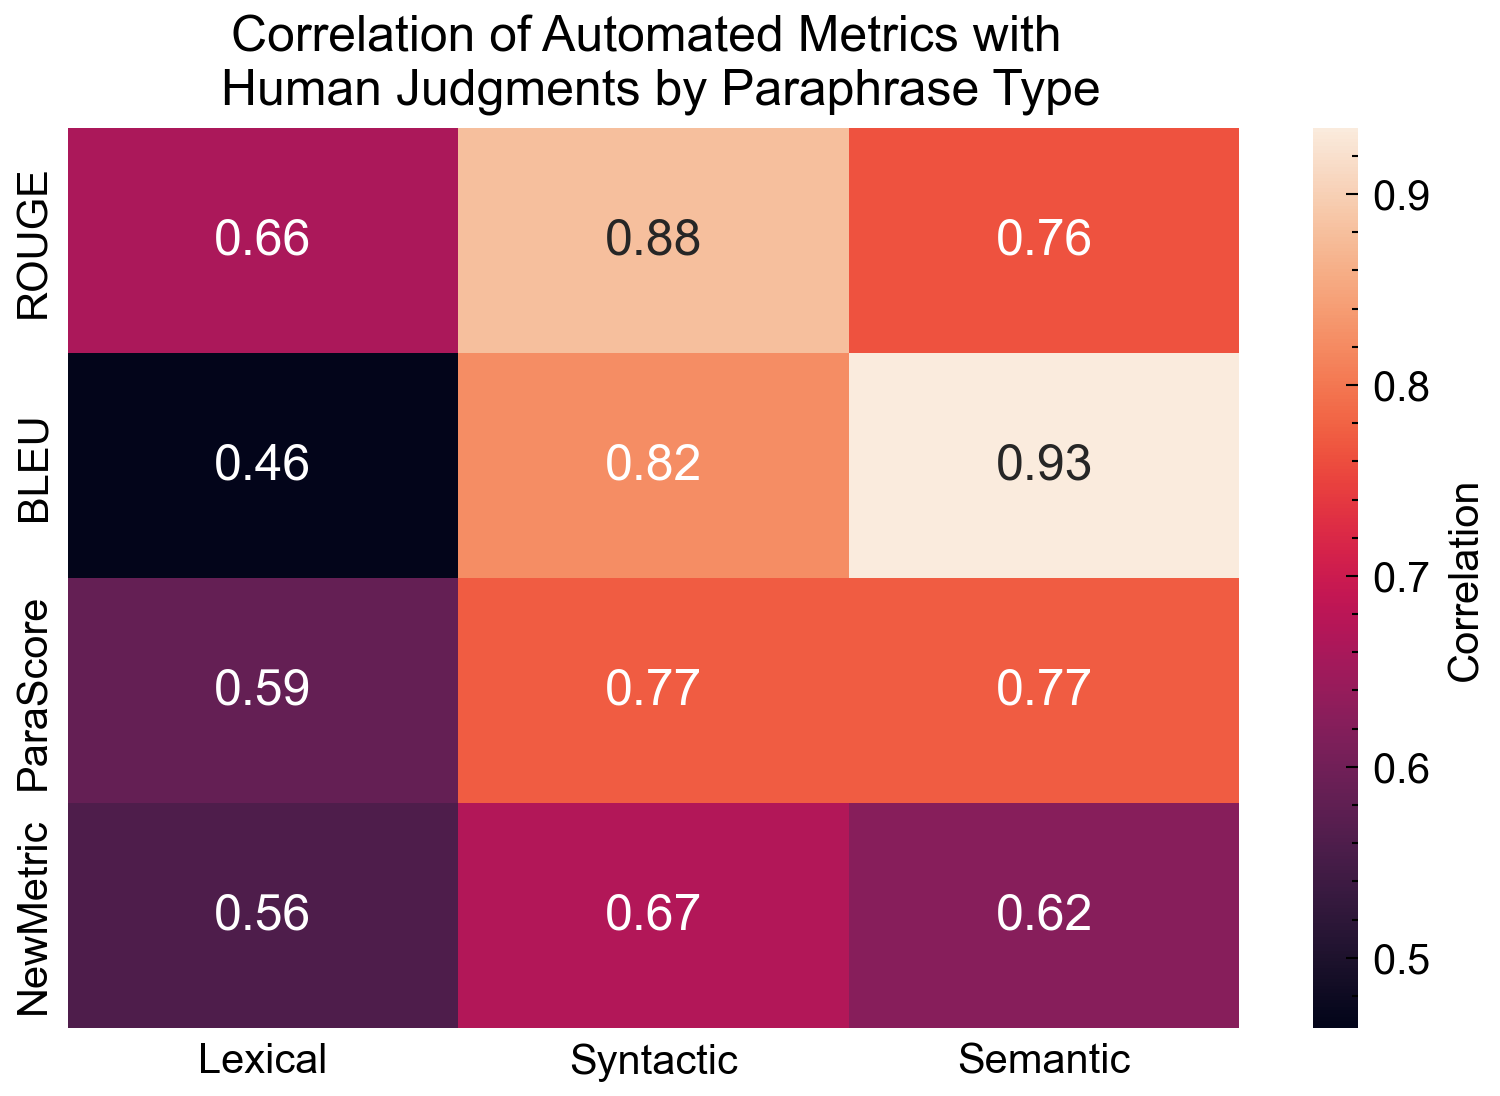

In [95]:
# Dummy data creation
paraphrase_types = ['Lexical', 'Syntactic', 'Semantic']
metrics = ['ROUGE', 'BLEU', 'ParaScore', 'NewMetric']

# Generate dummy correlation scores for each metric and paraphrase type
correlation_scores = {
    'Lexical': np.random.uniform(0.3, 0.8, size=4),
    'Syntactic': np.random.uniform(0.4, 0.9, size=4),
    'Semantic': np.random.uniform(0.5, 0.95, size=4)
}
# Create the DataFrame for heatmap
heatmap_data = pd.DataFrame(correlation_scores, index=metrics)

# Plot heatmap

fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

sns.heatmap(heatmap_data, annot=True, cbar_kws={'label': 'Correlation'}, annot_kws={"fontsize": 12})

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False)  # Remove tick marks on the x-axis
ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis


# Add title
plt.title('Correlation of Automated Metrics with \n Human Judgments by Paraphrase Type', fontsize=12)

# Save as a PDF
output_path = os.path.join(output_dir, "newcorrelation.pdf")
plt.savefig(output_path, dpi=300)

# Show plot
plt.show()


In [96]:
os.chdir('/home/slim/dpo-rhlf-paraphrase-types')
from notebooks.newmetric_llama2 import ParaphraseTypeEvaluator

evaluator = ParaphraseTypeEvaluator(model_name="out/cls-models/deberta-base_qqp_pd_etpc_ptd/run-16/checkpoint-184")
df_results = evaluator.evaluate(json_file_path="/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json")


Some weights of the model checkpoint at out/cls-models/deberta-base_qqp_pd_etpc_ptd/run-16/checkpoint-184 were not used when initializing DebertaForSequenceClassification: ['classifier.loss_fct.weight']
- This IS expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DebertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


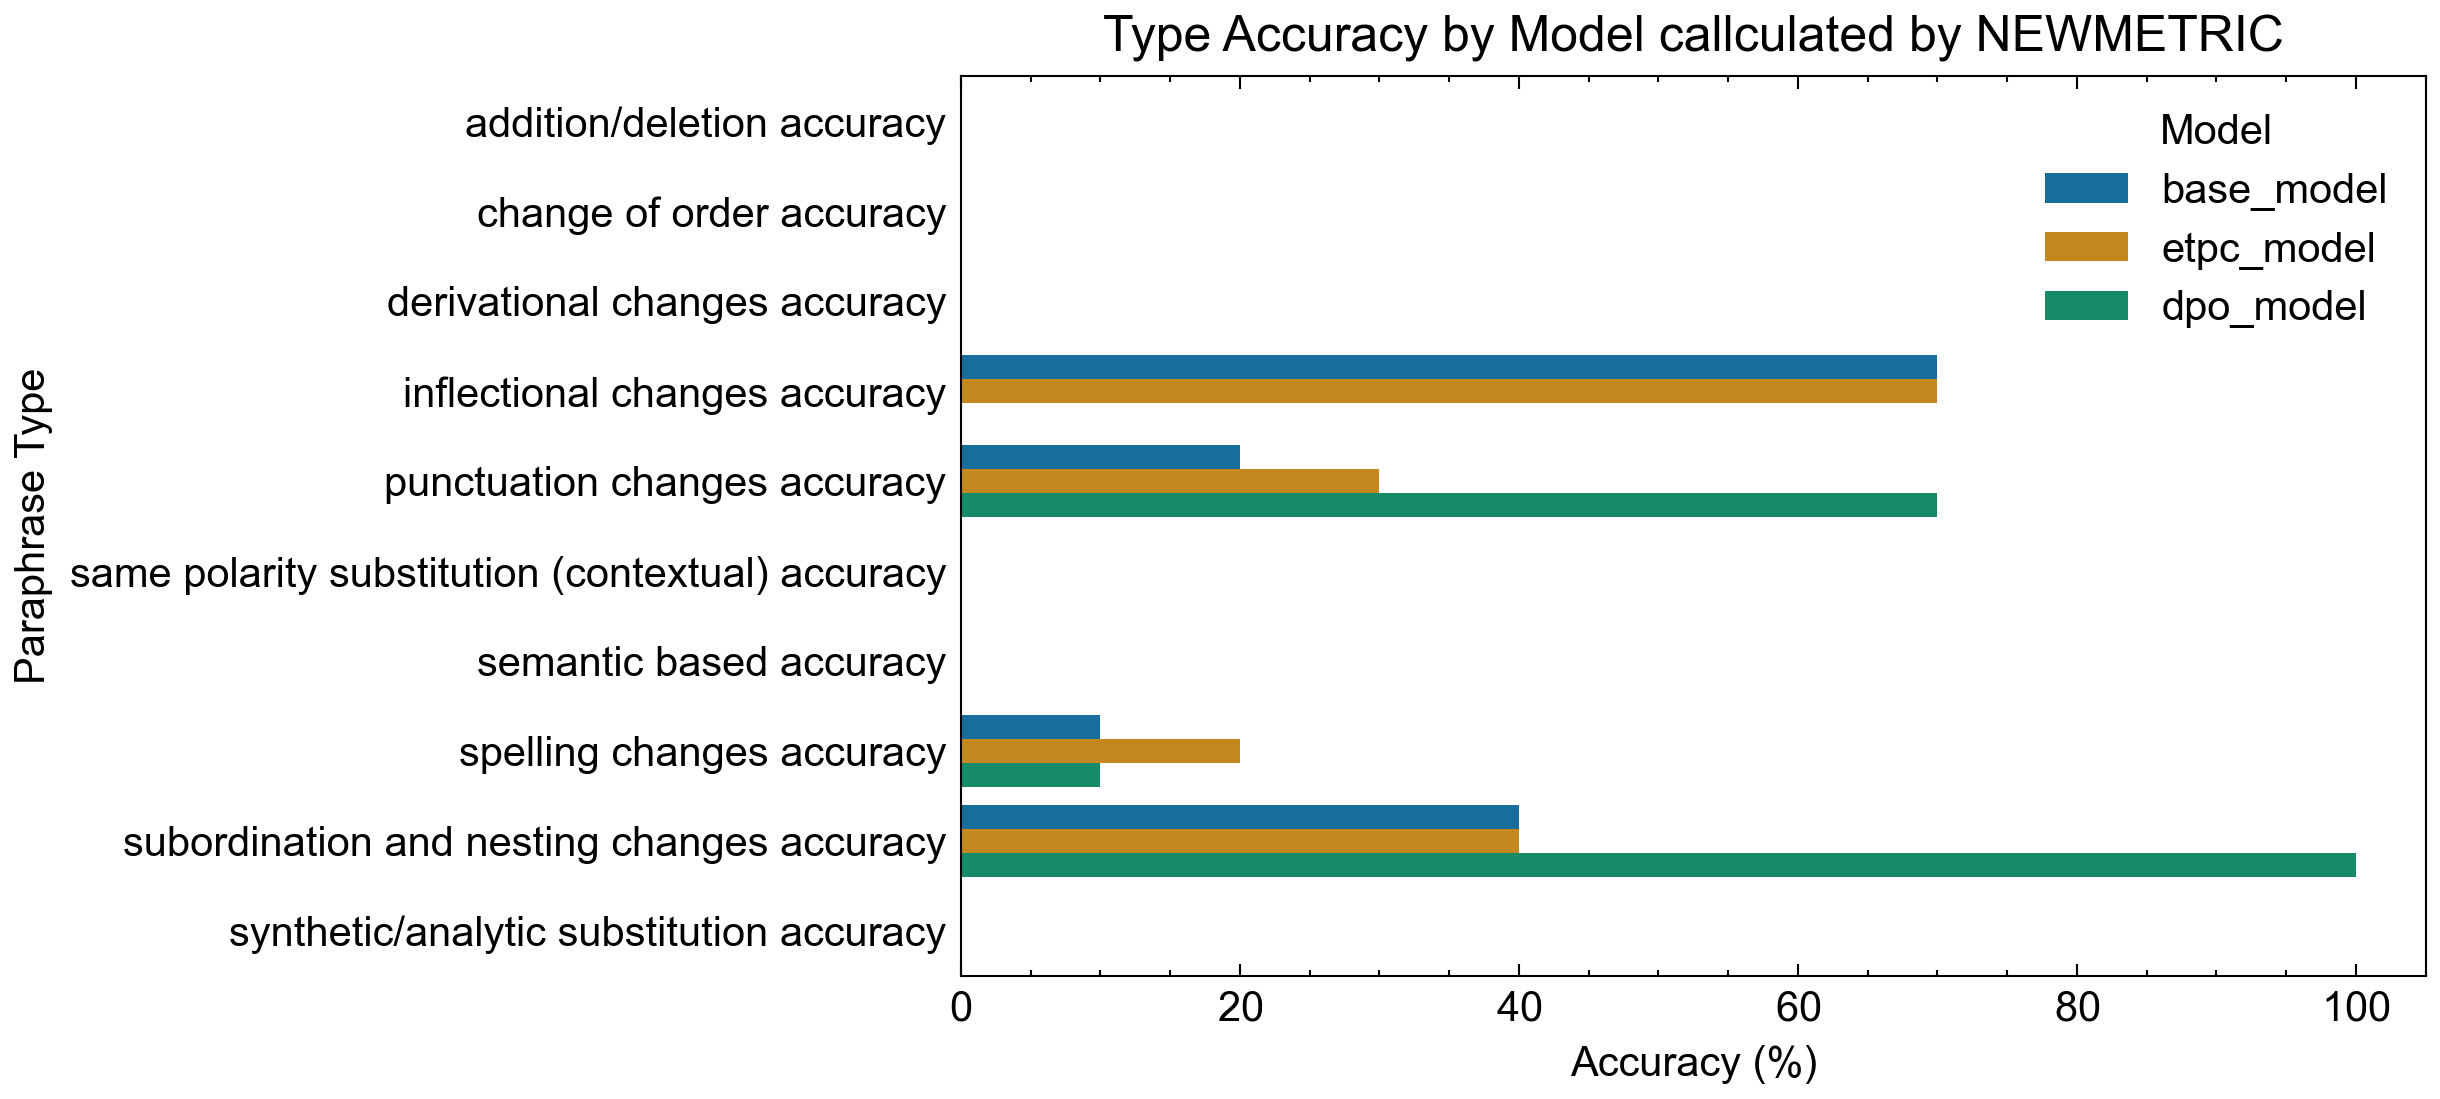

In [97]:
TOP_10_PARAPHRASE_TYPES = [
    "addition/deletion", "change of order", "derivational changes", "inflectional changes",
    "punctuation changes", "same polarity substitution (contextual)", "semantic based",
    "spelling changes", "subordination and nesting changes", "synthetic/analytic substitution"
]

# Melt the DataFrame to have a suitable format for plotting
df_melted = df_results.melt(
    id_vars=['Model'],
    value_vars=[f"{ptype} accuracy" for ptype in TOP_10_PARAPHRASE_TYPES],
    var_name='Paraphrase Type',
    value_name='Accuracy'
)

# Create a bar plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science','no-latex'])
sns.set_palette("colorblind")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
sns.barplot(
    data=df_melted,
    y='Paraphrase Type',
    x='Accuracy',
    hue='Model'
)

# Customize the plot
plt.title('Type Accuracy by Model callculated by NEWMETRIC')
plt.ylabel('Paraphrase Type')
ax.tick_params(axis='y', which='both', left=False, right=False)  # Remove tick marks on the y-axis
plt.xlabel('Accuracy (%)')
plt.legend(title='Model') 


# Show the plot
plt.show()



In [98]:
print("Results from NEWMETRIC")
print(df_results[["Model", "Single Accuracy"]])

Results from NEWMETRIC
        Model  Single Accuracy
0  base_model        11.290323
1  etpc_model        14.545455
2   dpo_model        16.363636
